# Epidemiological Intelligence — Modelagem Estatística: Comparação entre Doenças

## Objetivo

Este notebook **consolida** os resultados de modelagem climática já produzidos
nos seis notebooks de doença (`03_model_asma.ipynb` a
`08_model_leptospirose.ipynb`): ASMA, BRONQUITE AGUDA, BRONQUITE CRÔNICA,
INFARTO AGUDO DO MIOCÁRDIO, INSUFICIÊNCIA CARDÍACA e LEPTOSPIROSE.

Cada notebook de doença ajustou um modelo Binomial Negativo com efeitos de
município e mês (`cases ~ C(municipality) + C(month)`) como referência, e
testou se a adição de variáveis climáticas (contemporâneas e defasadas em 1 a
3 meses) melhora o desempenho de previsão **fora da amostra** (treino
2015–2023, teste 2024–2025), salvando os resultados em
`artifacts/modeling/{disease_key}_metrics.json` e
`artifacts/modeling/{disease_key}_predictions.parquet` via
`mu.save_disease_artifacts`.

Este notebook **não recalcula nenhum modelo e não acessa o BigQuery**: ele
apenas lê os artefatos já gerados (via `mu.load_disease_artifacts`) e os dados
brutos em cache local (via `mu.load_raw_data`, usado somente para reconstruir
o histórico de treino nos gráficos de backtest) para responder, de forma
consolidada, uma pergunta central:

> **Em que medida o clima ajuda a prever os casos mensais de cada doença,
> além do que já é explicado por município e sazonalidade (mês)?**

O objetivo é estritamente de **capacidade preditiva fora da amostra** e de
**comparação entre doenças** — não é um objetivo de detecção de surtos, nem
uma análise causal. Toda a interpretação segue a convenção do projeto: usar
linguagem como "associado a", "contribuiu para a previsão" ou "melhorou o
desempenho fora da amostra", nunca "causou" ou "provocou".


## 0. Imports

In [12]:
import sys
import re
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

import modeling_utils as mu

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", None)


## 1. Carregamento dos artefatos por doença

Os artefatos de cada doença (`{disease_key}_metrics.json` e
`{disease_key}_predictions.parquet`) já foram gerados pelos notebooks
individuais e são lidos aqui via `mu.load_disease_artifacts(disease_key)`,
que retorna `(metrics_dict, predictions_df)`. Nenhum modelo é reajustado e
nenhuma consulta ao BigQuery é feita nesta etapa.


**Correção metodológica aplicada (2023 como validação):** a versão inicial
dos 6 notebooks de doença testava cada variável climática e cada lag
avaliando diretamente no conjunto de teste 2024-2025 — o mesmo período usado
depois para reportar a performance final. Isso gera um viés otimista (a
variável "vencedora" entre ~10-25 candidatas tende a parecer melhor do que
realmente é, só por ter sido escolhida olhando para esse mesmo período).

Essa etapa foi corrigida: a seleção de variáveis/lags agora usa
`mu.feature_selection_split` (treino 2015-2022 / validação 2023), e o
conjunto de teste 2024-2025 só é usado uma única vez, no final, para reportar
a performance do modelo já definido — nunca para escolher features. Os
números consolidados abaixo já refletem essa correção. Em 2 das 6 doenças
(BRONQUITE CRÔNICA e INFARTO) o resultado final não mudou de forma relevante;
em 2 (ASMA e INSUFICIÊNCIA CARDÍACA) o ganho climático era real mas menor do
que o originalmente reportado; em 1 (BRONQUITE AGUDA) o ganho relatado antes
era majoritariamente um artefato do vazamento — o modelo climático corrigido
não supera o baseline no teste real; LEPTOSPIROSE manteve as mesmas features
mesmo sob a validação corrigida.

In [13]:
metrics_by_key = {}
predictions_by_key = {}

for disease_key, disease_name in mu.DISEASES.items():
    metrics, predictions = mu.load_disease_artifacts(disease_key)
    assert predictions is not None, f"Predições ausentes para {disease_key}"
    assert metrics["disease"] == disease_name, (
        f"Nome de doença inconsistente para {disease_key}: "
        f"{metrics['disease']!r} != {disease_name!r}"
    )
    metrics_by_key[disease_key] = metrics
    predictions_by_key[disease_key] = predictions
    print(
        f"OK  {disease_key:24s} -> {disease_name:28s} "
        f"metrics={len(metrics)} chaves, predictions={predictions.shape}"
    )

print(f"\n{len(metrics_by_key)} de {len(mu.DISEASES)} artefatos de doença carregados com sucesso.")


OK  asma                     -> ASMA                         metrics=25 chaves, predictions=(581, 4)
OK  bronquite_aguda          -> BRONQUITE AGUDA              metrics=25 chaves, predictions=(564, 4)
OK  bronquite_cronica        -> BRONQUITE CRÔNICA            metrics=26 chaves, predictions=(575, 4)
OK  infarto                  -> INFARTO AGUDO DO MIOCÁRDIO   metrics=25 chaves, predictions=(578, 4)
OK  insuficiencia_cardiaca   -> INSUFICIÊNCIA CARDÍACA       metrics=26 chaves, predictions=(590, 4)
OK  leptospirose             -> LEPTOSPIROSE                 metrics=28 chaves, predictions=(434, 4)

6 de 6 artefatos de doença carregados com sucesso.


## 2. Tabela comparativa principal

A tabela abaixo consolida, para cada doença, o desempenho do modelo-base
(apenas município + mês) contra o modelo final (município + mês + clima
selecionado), sempre avaliado no período de teste (2024–2025), fora da
amostra de treino.


In [14]:
main_cols = [
    "disease", "baseline_mae", "model_mae", "mae_improvement_pct",
    "baseline_rmse", "model_rmse", "rmse_improvement_pct",
    "r2_test", "wape_pct", "alpha", "train_n", "test_n",
    "converged", "selected_features",
]

main_rows = []
for disease_key, metrics in metrics_by_key.items():
    row = {"disease_key": disease_key}
    row.update({col: metrics[col] for col in main_cols})
    main_rows.append(row)

main_df = (
    pd.DataFrame(main_rows)[["disease_key"] + main_cols]
    .sort_values("rmse_improvement_pct", ascending=False)
    .reset_index(drop=True)
)

display_df = main_df.copy()
display_df["selected_features"] = display_df["selected_features"].apply(
    lambda feats: ", ".join(feats) if feats else "(nenhuma)"
)
round_cols = [
    "baseline_mae", "model_mae", "mae_improvement_pct",
    "baseline_rmse", "model_rmse", "rmse_improvement_pct",
    "r2_test", "wape_pct", "alpha",
]
display_df[round_cols] = display_df[round_cols].round(2)

display(display_df.drop(columns=["disease_key"]))


,disease,baseline_mae,model_mae,mae_improvement_pct,baseline_rmse,model_rmse,rmse_improvement_pct,r2_test,wape_pct,alpha,train_n,test_n,converged,selected_features
0,INSUFICIÊNCIA CARDÍACA,5.75,5.57,3.00,12.48,11.99,3.89,0.96,25.83,0.07,2790,590,True,"atmospheric_pressure_avg_mb, dew_point_avg_c"
1,BRONQUITE CRÔNICA,4.04,4.01,0.97,7.46,7.26,2.67,0.94,34.96,0.24,2771,575,True,wind_gust_max_ms
2,LEPTOSPIROSE,1.22,1.18,2.68,7.99,7.82,2.05,0.10,91.09,0.23,1570,434,True,"precipitation_sum_mm_lag1, relative_humidity_avg_pct_lag1"
3,INFARTO AGUDO DO MIOCÁRDIO,6.73,6.64,1.31,18.10,17.77,1.82,0.92,30.02,0.09,2746,578,True,wind_speed_avg_ms_lag1
4,ASMA,2.92,2.89,0.82,9.60,9.45,1.53,0.87,40.63,0.34,2739,581,True,"relative_humidity_avg_pct, dew_point_avg_c_lag1"
5,BRONQUITE AGUDA,5.12,5.17,-0.92,18.11,18.64,-2.95,0.90,34.92,0.76,2594,564,True,"relative_humidity_avg_pct, precipitation_avg_observation_mm_lag3"


## 3. Comparação gráfica entre doenças

Os quatro gráficos a seguir usam a mesma ordenação da tabela principal
(melhoria de RMSE decrescente), para facilitar a leitura cruzada entre
métricas.


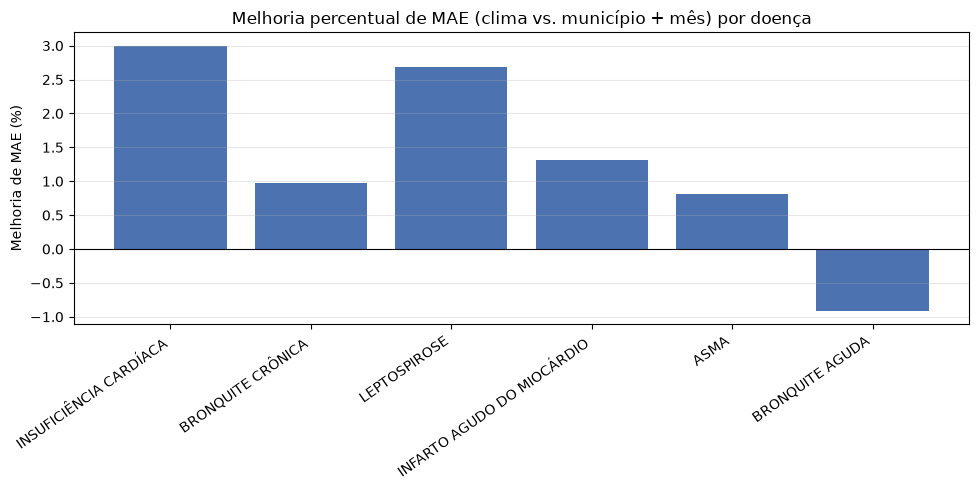

In [15]:
order = main_df["disease"].tolist()

plt.figure(figsize=(10, 5))
plt.bar(order, main_df["mae_improvement_pct"], color="#4C72B0")
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Melhoria de MAE (%)")
plt.title("Melhoria percentual de MAE (clima vs. município + mês) por doença")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


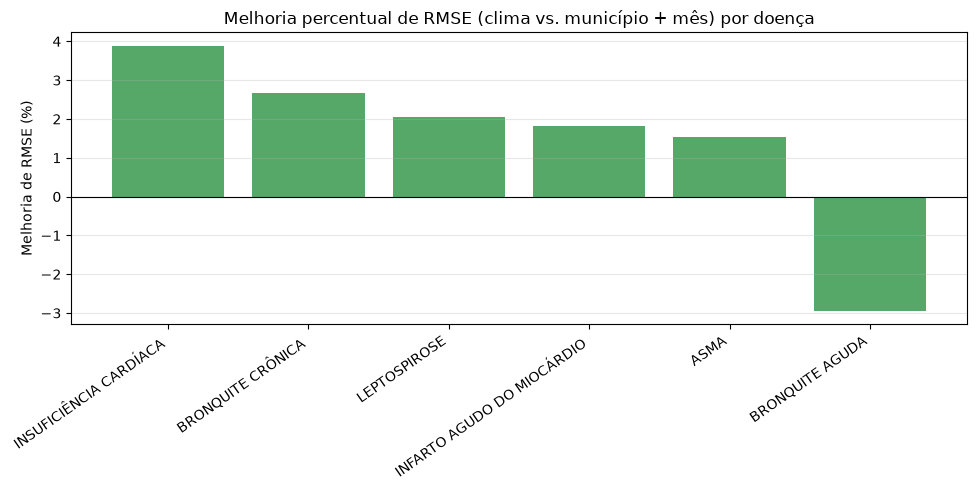

In [16]:
plt.figure(figsize=(10, 5))
plt.bar(order, main_df["rmse_improvement_pct"], color="#55A868")
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Melhoria de RMSE (%)")
plt.title("Melhoria percentual de RMSE (clima vs. município + mês) por doença")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


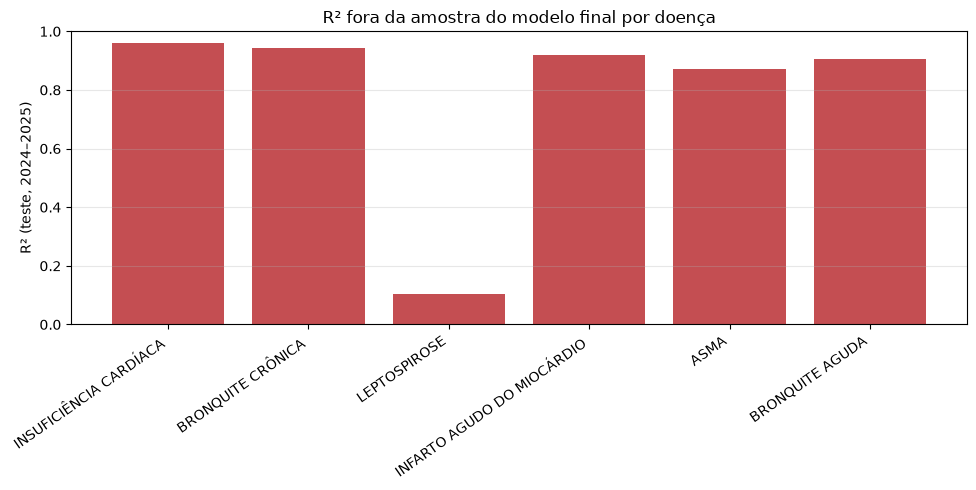

In [17]:
plt.figure(figsize=(10, 5))
plt.bar(order, main_df["r2_test"], color="#C44E52")
plt.ylabel("R² (teste, 2024–2025)")
plt.title("R² fora da amostra do modelo final por doença")
plt.xticks(rotation=35, ha="right")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


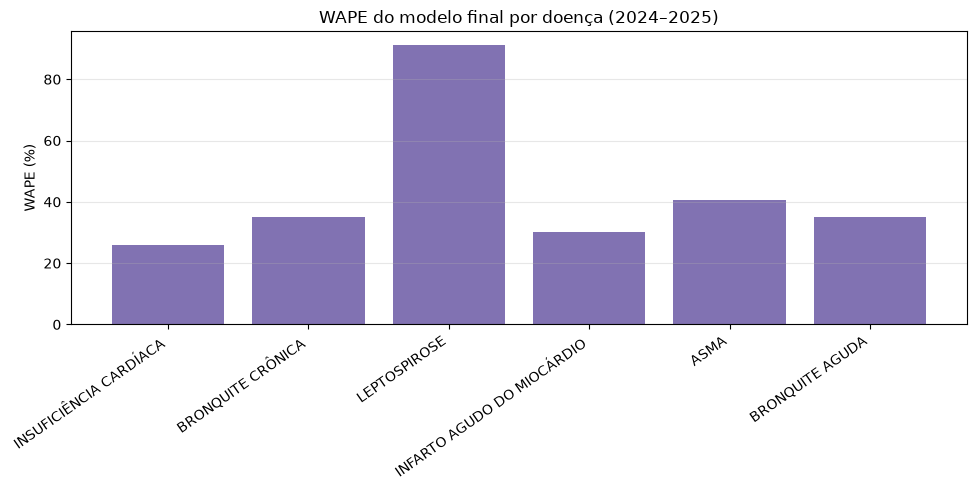

In [18]:
plt.figure(figsize=(10, 5))
plt.bar(order, main_df["wape_pct"], color="#8172B2")
plt.ylabel("WAPE (%)")
plt.title("WAPE do modelo final por doença (2024–2025)")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


**Nota sobre o WAPE:** o WAPE (erro percentual absoluto ponderado) mede o
erro relativo ao volume total de casos observados no período, mas **não deve
ser lido como "acurácia"** do modelo — especialmente para doenças com poucos
casos por município/mês (como LEPTOSPIROSE), onde um WAPE alto pode conviver
com um bom ajuste absoluto (MAE/RMSE baixos) simplesmente porque o
denominador (soma de casos reais) é pequeno.


## 4. Backtest por município (uma doença por gráfico)

Os artefatos de predição (`predictions_df`) cobrem apenas o período de teste
(2024–2025). Para visualizar o histórico completo (2015–2023 + previsão
2024–2025) é necessário carregar os dados brutos uma única vez via
`mu.load_raw_data()` (leitura do cache local, sem BigQuery) e filtrar por
doença e município.

Para cada doença, o município exibido é **PORTO ALEGRE quando ela tiver
dados** (treino ou teste) para aquela doença; caso contrário, é usado o
município de maior volume de casos nas previsões da doença — a escolha é
verificada programaticamente, não assumida.


ASMA: município selecionado = PORTO ALEGRE (Porto Alegre possui dados para esta doença)


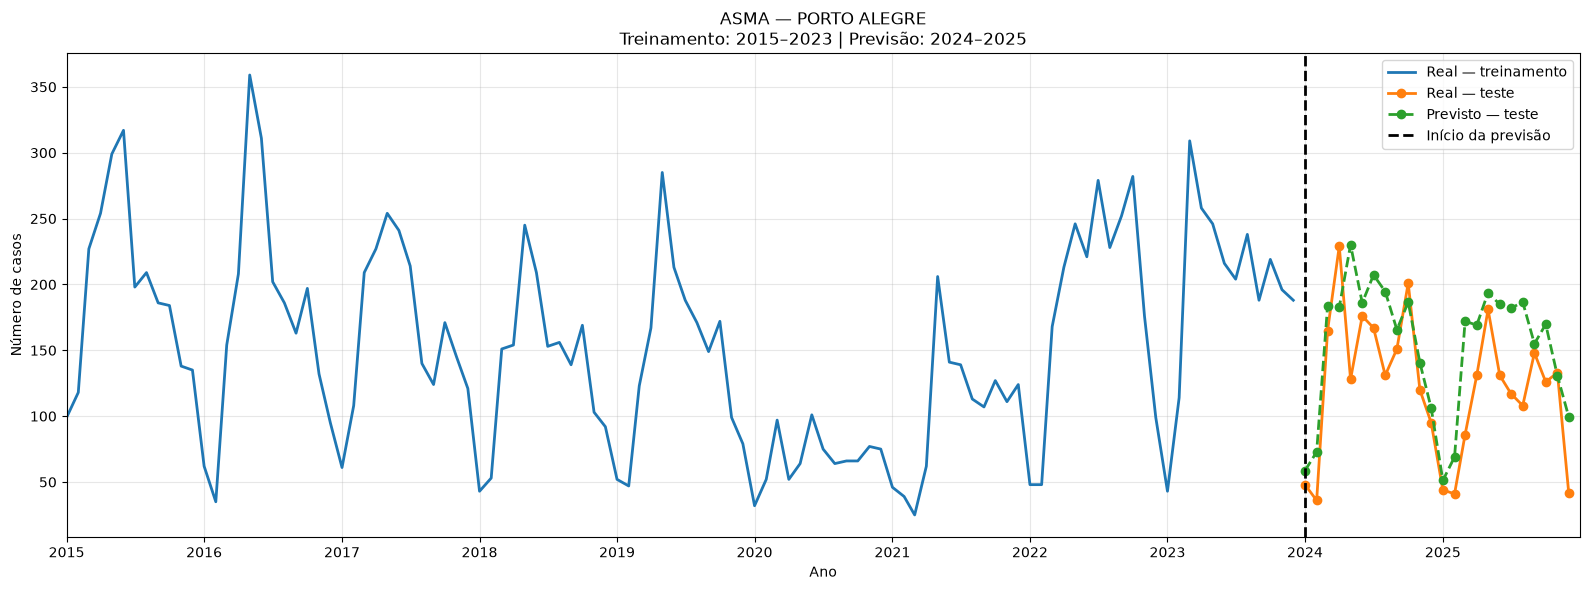

BRONQUITE AGUDA: município selecionado = PORTO ALEGRE (Porto Alegre possui dados para esta doença)


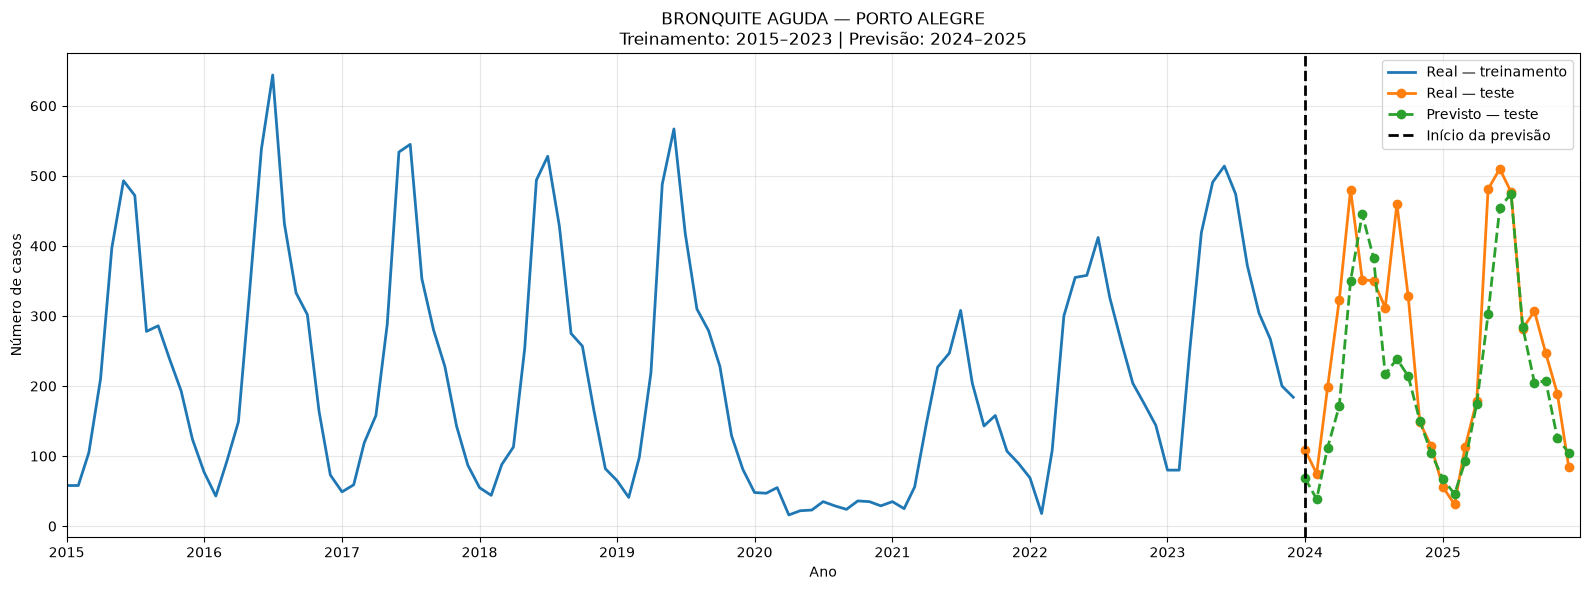

BRONQUITE CRÔNICA: município selecionado = PORTO ALEGRE (Porto Alegre possui dados para esta doença)


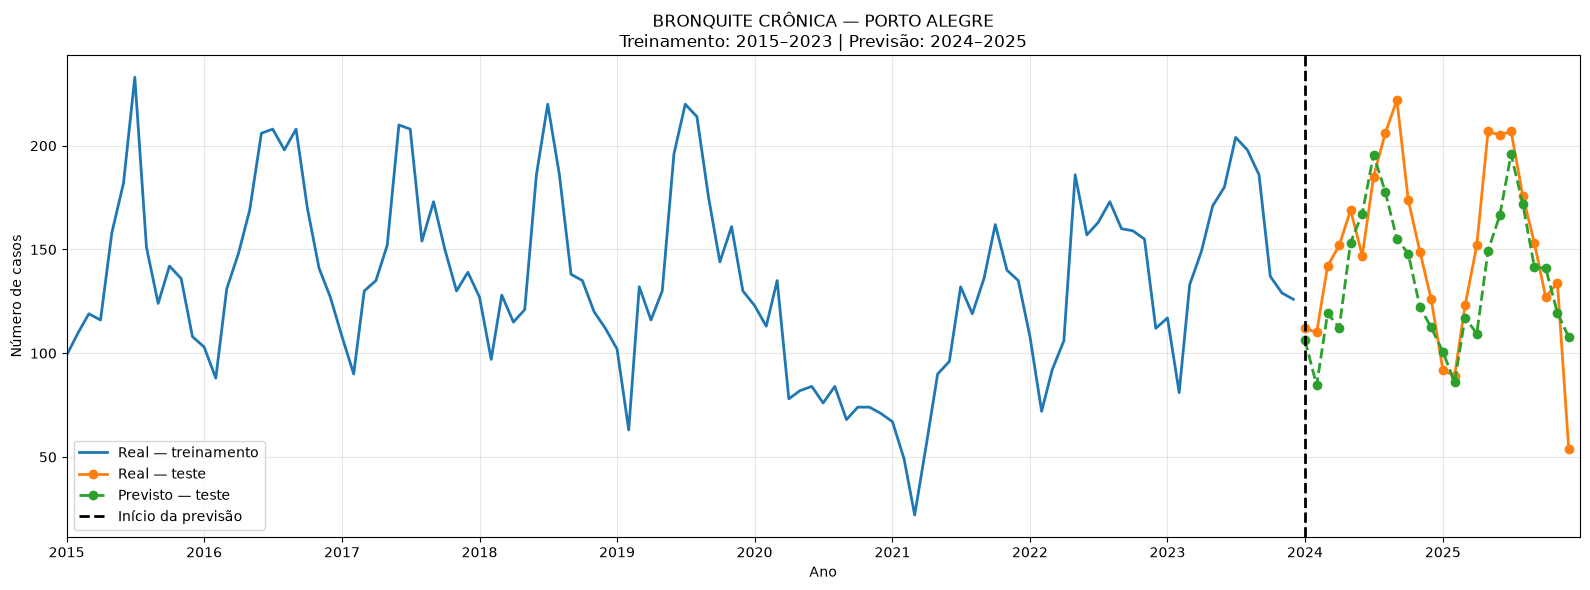

INFARTO AGUDO DO MIOCÁRDIO: município selecionado = PORTO ALEGRE (Porto Alegre possui dados para esta doença)


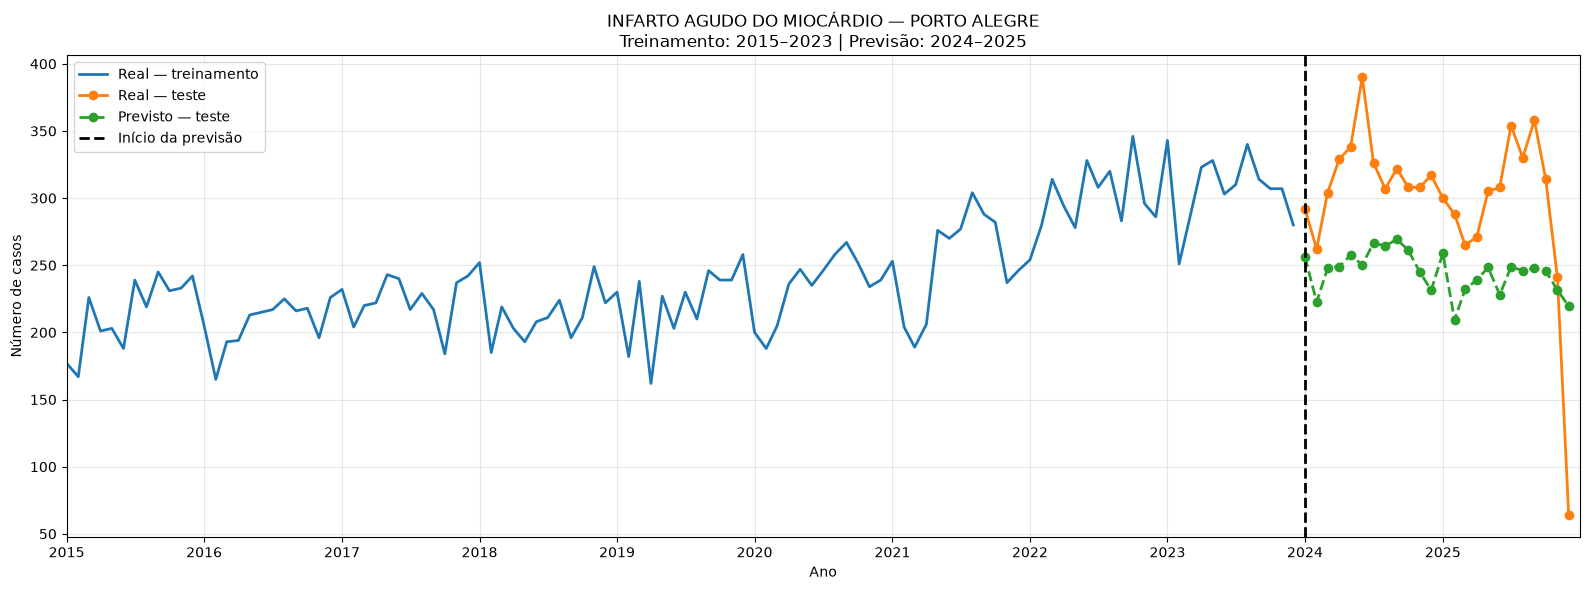

INSUFICIÊNCIA CARDÍACA: município selecionado = PORTO ALEGRE (Porto Alegre possui dados para esta doença)


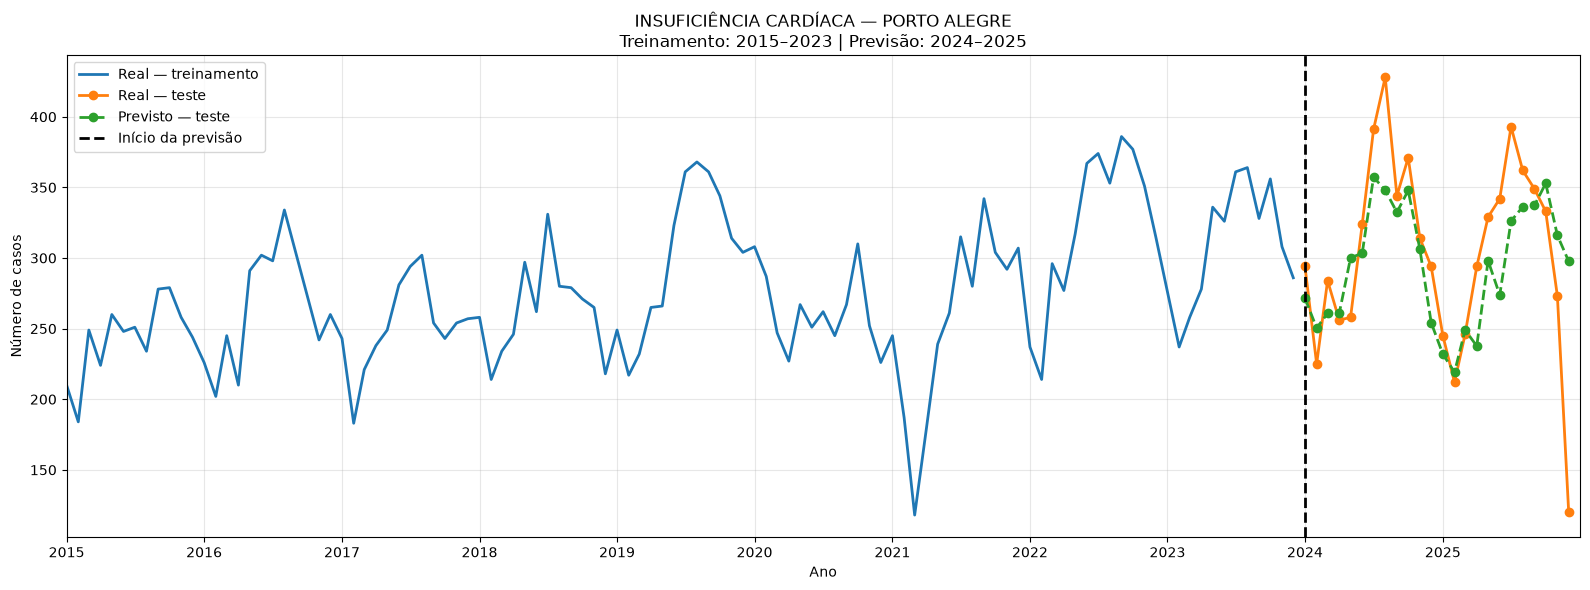

LEPTOSPIROSE: município selecionado = PORTO ALEGRE (Porto Alegre possui dados para esta doença)


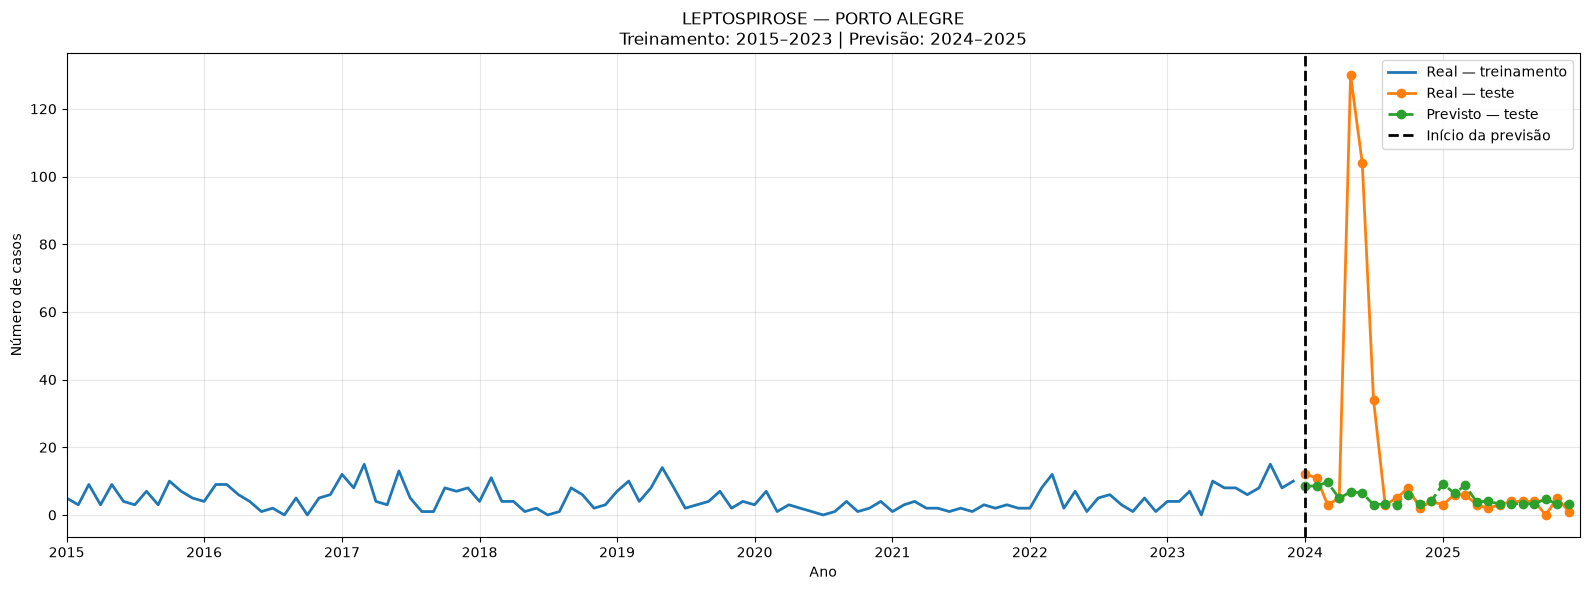

In [19]:
raw_df = mu.load_raw_data()

for disease_key, disease_name in mu.DISEASES.items():
    metrics = metrics_by_key[disease_key]
    forecast_df = predictions_by_key[disease_key]

    historical_df = (
        raw_df[
            (raw_df["disease"] == disease_name)
            & (raw_df["reference_date"] < mu.TRAIN_CUTOFF)
        ][["municipality", "reference_date", "cases"]]
        .copy()
    )
    historical_df["cases"] = historical_df["cases"].astype("float64")

    available_municipalities = set(historical_df["municipality"]) | set(forecast_df["municipality"])

    if "PORTO ALEGRE" in available_municipalities:
        municipio = "PORTO ALEGRE"
        motivo = "Porto Alegre possui dados para esta doença"
    else:
        volume_by_municipio = forecast_df.groupby("municipality")["cases"].sum()
        municipio = volume_by_municipio.idxmax()
        motivo = "Porto Alegre não possui dados para esta doença; maior volume de casos no teste"

    print(f"{disease_name}: município selecionado = {municipio} ({motivo})")

    plot_backtest = mu.make_backtest_plotter(disease_name, historical_df, forecast_df)
    plot_backtest(municipio)


## Comparação geral das doenças

In [20]:
FEATURE_LAG_RE = re.compile(r"^(?P<base>.+)_lag(?P<lag>[123])$")


def split_feature_lag(feature_name: str):
    match = FEATURE_LAG_RE.match(feature_name)
    if match:
        return match.group("base"), int(match.group("lag"))
    return feature_name, 0


base_variable_counter = {}
lag_counter = {0: 0, 1: 0, 2: 0, 3: 0}
total_selected_features = 0

for metrics in metrics_by_key.values():
    for feature in metrics["selected_features"]:
        base, lag = split_feature_lag(feature)
        base_variable_counter[base] = base_variable_counter.get(base, 0) + 1
        lag_counter[lag] += 1
        total_selected_features += 1

base_variable_freq = (
    pd.Series(base_variable_counter, name="n_doencas")
    .sort_values(ascending=False)
    .rename_axis("variavel_climatica_base")
    .reset_index()
)
lag_freq = (
    pd.Series(lag_counter, name="n_ocorrencias")
    .rename_axis("lag_meses")
    .reset_index()
    .sort_values("lag_meses")
)

best_row = main_df.iloc[main_df["rmse_improvement_pct"].idxmax()]
worst_row = main_df.iloc[main_df["rmse_improvement_pct"].idxmin()]

mean_rmse_gain = main_df["rmse_improvement_pct"].mean()

seasonality_explains_most = main_df[
    (main_df["r2_test"] >= 0.90) & (main_df["rmse_improvement_pct"] <= mean_rmse_gain)
]
climate_adds_value = main_df[main_df["rmse_improvement_pct"] > mean_rmse_gain]

leptospirose_row = main_df[main_df["disease"] == mu.DISEASES["leptospirose"]].iloc[0]

top_base_variable = base_variable_freq.iloc[0]
top_lag_row = lag_freq.sort_values("n_ocorrencias", ascending=False).iloc[0]

print("Frequência das variáveis climáticas base nos `selected_features`:")
display(base_variable_freq)
print("\nFrequência dos lags nos `selected_features` (0 = variável contemporânea):")
display(lag_freq)


Frequência das variáveis climáticas base nos `selected_features`:


,variavel_climatica_base,n_doencas
0,relative_humidity_avg_pct,3
1,dew_point_avg_c,2
2,precipitation_avg_observation_mm,1
3,wind_gust_max_ms,1
4,wind_speed_avg_ms,1
5,atmospheric_pressure_avg_mb,1
6,precipitation_sum_mm,1



Frequência dos lags nos `selected_features` (0 = variável contemporânea):


,lag_meses,n_ocorrencias
0,0,5
1,1,4
2,2,0
3,3,1


In [21]:
summary_lines = []

summary_lines.append(
    f"- **Maior ganho climático de RMSE:** {best_row['disease']} "
    f"(melhoria de {best_row['rmse_improvement_pct']:.2f}% no RMSE de teste em relação "
    f"ao modelo apenas com município + mês; R² de teste = {best_row['r2_test']:.3f})."
)
worst_gain = worst_row["rmse_improvement_pct"]
worst_gain_desc = (
    f"melhoria de {worst_gain:.2f}% no RMSE de teste"
    if worst_gain >= 0
    else f"o modelo climático teve desempenho PIOR que o baseline "
         f"(RMSE {abs(worst_gain):.2f}% maior no teste)"
)
summary_lines.append(
    f"- **Menor ganho climático de RMSE:** {worst_row['disease']} "
    f"({worst_gain_desc}; R² de teste = {worst_row['r2_test']:.3f})."
)

if len(seasonality_explains_most) > 0:
    doencas_sazonalidade = ", ".join(seasonality_explains_most["disease"].tolist())
    summary_lines.append(
        "- **Município + sazonalidade já explicam quase tudo** (R² de teste ≥ 0,90 e "
        f"ganho de RMSE abaixo da média das 6 doenças, {mean_rmse_gain:.2f}%) em: "
        f"{doencas_sazonalidade}. Nesses casos, o modelo-base sem clima já captura a maior "
        "parte do padrão sazonal e municipal dos casos."
    )
else:
    summary_lines.append(
        "- Nenhuma doença combinou simultaneamente R² de teste ≥ 0,90 e ganho de RMSE "
        f"abaixo da média das 6 doenças ({mean_rmse_gain:.2f}%)."
    )

if len(climate_adds_value) > 0:
    doencas_clima = ", ".join(
        f"{r['disease']} (+{r['rmse_improvement_pct']:.2f}% RMSE)"
        for _, r in climate_adds_value.iterrows()
    )
    summary_lines.append(
        f"- **Clima acrescentou informação preditiva relevante** (ganho de RMSE acima da "
        f"média das 6 doenças, {mean_rmse_gain:.2f}%) em: {doencas_clima}. Mesmo nesses "
        "casos o ganho é moderado — o clima **contribuiu para a previsão**, mas não "
        "substitui município e sazonalidade como principais fatores explicativos."
    )

summary_lines.append(
    f"- **Variável climática de base mais frequente** entre os `selected_features` das 6 "
    f"doenças: `{top_base_variable['variavel_climatica_base']}` "
    f"({int(top_base_variable['n_doencas'])} de {total_selected_features} seleções no total)."
)
summary_lines.append(
    f"- **Lag mais frequente** entre as features selecionadas: {int(top_lag_row['lag_meses'])} "
    f"{'mês (variável contemporânea)' if top_lag_row['lag_meses'] == 0 else 'mês(es) de defasagem'} "
    f"({int(top_lag_row['n_ocorrencias'])} de {total_selected_features} ocorrências)."
)
summary_lines.append(
    f"- **LEPTOSPIROSE** teve o menor R² de teste entre as 6 doenças ({leptospirose_row['r2_test']:.3f}) "
    "e um ganho climático de RMSE modesto "
    f"({leptospirose_row['rmse_improvement_pct']:.2f}%), mas seu período de teste inclui um "
    "pico anômalo de casos associado às enchentes do Rio Grande do Sul em 2024 (ver nota "
    "específica no fechamento). Isso limita a comparabilidade direta do ganho de "
    "LEPTOSPIROSE com as demais doenças, que não passaram por eventos extremos "
    "equivalentes no período de teste."
)

display(Markdown("\n".join(summary_lines)))


- **Maior ganho climático de RMSE:** INSUFICIÊNCIA CARDÍACA (melhoria de 3.89% no RMSE de teste em relação ao modelo apenas com município + mês; R² de teste = 0.960).
- **Menor ganho climático de RMSE:** BRONQUITE AGUDA (o modelo climático teve desempenho PIOR que o baseline (RMSE 2.95% maior no teste); R² de teste = 0.904).
- **Município + sazonalidade já explicam quase tudo** (R² de teste ≥ 0,90 e ganho de RMSE abaixo da média das 6 doenças, 1.50%) em: BRONQUITE AGUDA. Nesses casos, o modelo-base sem clima já captura a maior parte do padrão sazonal e municipal dos casos.
- **Clima acrescentou informação preditiva relevante** (ganho de RMSE acima da média das 6 doenças, 1.50%) em: INSUFICIÊNCIA CARDÍACA (+3.89% RMSE), BRONQUITE CRÔNICA (+2.67% RMSE), LEPTOSPIROSE (+2.05% RMSE), INFARTO AGUDO DO MIOCÁRDIO (+1.82% RMSE), ASMA (+1.53% RMSE). Mesmo nesses casos o ganho é moderado — o clima **contribuiu para a previsão**, mas não substitui município e sazonalidade como principais fatores explicativos.
- **Variável climática de base mais frequente** entre os `selected_features` das 6 doenças: `relative_humidity_avg_pct` (3 de 10 seleções no total).
- **Lag mais frequente** entre as features selecionadas: 0 mês (variável contemporânea) (5 de 10 ocorrências).
- **LEPTOSPIROSE** teve o menor R² de teste entre as 6 doenças (0.105) e um ganho climático de RMSE modesto (2.05%), mas seu período de teste inclui um pico anômalo de casos associado às enchentes do Rio Grande do Sul em 2024 (ver nota específica no fechamento). Isso limita a comparabilidade direta do ganho de LEPTOSPIROSE com as demais doenças, que não passaram por eventos extremos equivalentes no período de teste.

## 5. Coeficientes e p-values das features climáticas selecionadas

Uma linha por feature climática presente no modelo final de cada doença
(`selected_features`), com o coeficiente e o p-value do modelo Binomial
Negativo final (extraídos de `coefficients` e `pvalues` nos artefatos de
métricas). `lag = 0` indica a variável contemporânea (sem defasagem);
`lag = 1, 2, 3` indica a defasagem em meses (sufixo `_lagN` removido do nome
da variável na coluna `feature`).

**Coeficiente estatisticamente significativo (p-value baixo) não é o mesmo
que capacidade preditiva relevante**: uma variável pode ter p-value pequeno e
ainda assim contribuir pouco para a redução de MAE/RMSE fora da amostra (e
vice-versa) — por isso a seleção final de cada doença considerou as duas
dimensões conjuntamente, não apenas o p-value.


In [22]:
feature_rows = []
for disease_key, metrics in metrics_by_key.items():
    coefficients = metrics["coefficients"]
    pvalues = metrics["pvalues"]
    for feature in metrics["selected_features"]:
        base, lag = split_feature_lag(feature)
        feature_rows.append({
            "disease": metrics["disease"],
            "feature": base,
            "lag": lag,
            "coef": coefficients.get(feature, np.nan),
            "pvalue": pvalues.get(feature, np.nan),
        })

features_table = pd.DataFrame(feature_rows, columns=["disease", "feature", "lag", "coef", "pvalue"])

with pd.option_context("display.float_format", lambda v: f"{v:.6g}"):
    display(features_table)


,disease,feature,lag,coef,pvalue
0,ASMA,relative_humidity_avg_pct,0,0.0105893,0.00208676
1,ASMA,dew_point_avg_c,1,0.034897,0.0023448
2,BRONQUITE AGUDA,relative_humidity_avg_pct,0,0.0104423,0.0122295
3,BRONQUITE AGUDA,precipitation_avg_observation_mm,3,-0.701788,0.000870953
4,BRONQUITE CRÔNICA,wind_gust_max_ms,0,0.00605692,0.0357156
5,INFARTO AGUDO DO MIOCÁRDIO,wind_speed_avg_ms,1,0.0851646,1.4646e-05
6,INSUFICIÊNCIA CARDÍACA,atmospheric_pressure_avg_mb,0,0.0324101,1.46123e-06
7,INSUFICIÊNCIA CARDÍACA,dew_point_avg_c,0,0.0302347,2.17652e-08
8,LEPTOSPIROSE,precipitation_sum_mm,1,0.00119341,0.0163516
9,LEPTOSPIROSE,relative_humidity_avg_pct,1,0.0415874,5.50357e-05


## Considerações finais

- **Linguagem não-causal:** todos os resultados acima descrevem associação
  estatística e desempenho preditivo fora da amostra — nunca relação causal.
  Uma variável climática selecionada em um modelo final "está associada a" ou
  "contribuiu para a previsão" dos casos de uma doença, e o clima, quando
  presente no modelo final, "melhorou o desempenho fora da amostra" em
  relação ao modelo apenas com município e mês. Em nenhum momento se deve
  afirmar que uma variável climática "causou", "provocou" ou "aumentou
  necessariamente" os casos de uma doença — os modelos aqui são
  observacionais e não foram desenhados para inferência causal.

- **Significância estatística ≠ capacidade preditiva:** um p-value baixo
  indica que o coeficiente estimado dificilmente seria observado por acaso
  sob o modelo ajustado, mas não garante, por si só, um ganho relevante de
  MAE/RMSE fora da amostra — e o inverso também ocorre. A seleção final de
  features em cada notebook de doença considerou as duas dimensões em
  conjunto (mais plausibilidade epidemiológica e baixa multicolinearidade),
  e esta consolidação preserva essa distinção ao reportar lado a lado o
  ganho preditivo (tabela principal) e os coeficientes/p-values (tabela de
  features).

- **LEPTOSPIROSE e o evento extremo de 2024:** o período de teste de
  LEPTOSPIROSE inclui um pico anômalo de casos em Porto Alegre em
  maio/junho de 2024, associado às enchentes no Rio Grande do Sul. Esses
  dados foram mantidos sem tratamento especial (sem remoção de outlier, sem
  ajuste), pois **nenhum dos modelos deste projeto foi otimizado para
  detecção de surtos ou eventos extremos** — o objetivo é exclusivamente
  avaliar ganho preditivo médio fora da amostra. Esse evento é tratado como
  uma **limitação** do modelo de LEPTOSPIROSE, e não como um objetivo
  alcançado ou não; por isso, o ganho climático medido para LEPTOSPIROSE
  não deve ser comparado diretamente ao das demais doenças, que não tiveram
  eventos extremos equivalentes no período de teste.


- **Abordagens alternativas testadas para LEPTOSPIROSE:** dado o baixo R²
  (≈0,10) e a alta proporção de meses/municípios com zero casos (~69% no
  treino), o notebook `08_model_leptospirose.ipynb` testou, como experimento
  exploratório adicional (fora do modelo oficial usado nesta comparação),
  duas alternativas à Binomial Negativa com efeitos fixos: um modelo
  Zero-Inflated Negative Binomial (ZINB) e um modelo hierárquico (Poisson
  com intercepto aleatório por município). Nenhuma das duas alternativas
  superou a Binomial Negativa oficial de forma relevante — o ZINB convergiu
  para previsões praticamente idênticas (a inflação de zeros já é absorvida
  pelos efeitos fixos de município) e o Poisson hierárquico teve um ganho
  marginal (~0,4-0,5% em MAE/RMSE) mas sem um parâmetro de dispersão
  equivalente ao alpha da NB, dentro do que é razoável atribuir a ruído de
  um único ajuste. Por isso o modelo oficial de LEPTOSPIROSE permanece a
  Binomial Negativa, mantendo o mesmo contrato de artefato usado pelas
  outras 5 doenças; os detalhes do experimento estão no notebook 08.